Q-1 .. How Many Movies Vs Tv Shows.... 
Chart Type - Bar ...

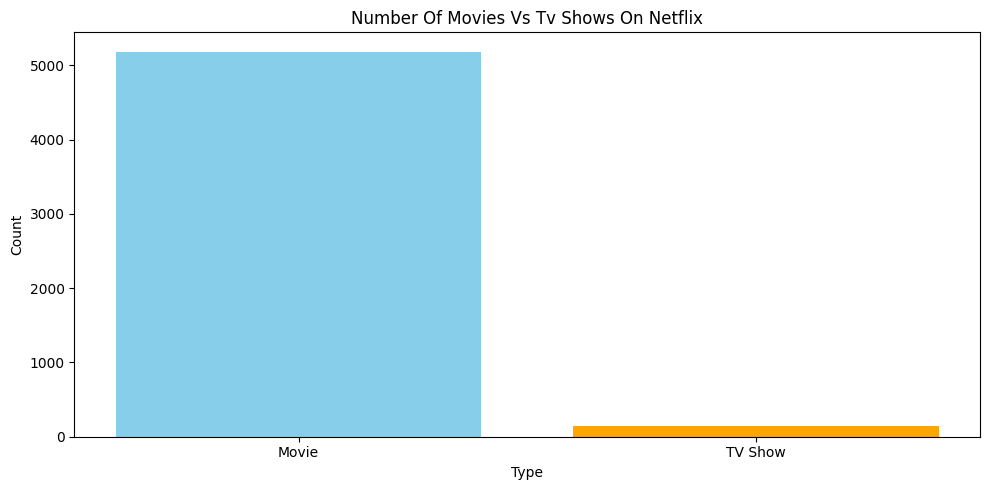

In [30]:
# step-1 _ Import The Libraries...

import pandas as pd
import matplotlib.pyplot as plt

# step-2_ Load The Data...

df = pd.read_csv("netflix_titles.csv")

# Step-3_ CLean The Data...

df = df.dropna(subset = ["show_id" , "type" , "title" , "director" , "cast" , "country" , "date_added" , "release_year" , "rating" , "duration" , "listed_in" , "description" ])

typecount = df["type"].value_counts()
plt.figure(figsize = (10, 5))
plt.bar(typecount.index , typecount.values , color = ["Skyblue" , "Orange"])
plt.xlabel("Type")
plt.ylabel("Count")
plt.title("Number Of Movies Vs Tv Shows On Netflix")
plt.tight_layout()  
plt.savefig("Movies Vs Tv Shows On Netflix.png")
plt.show()



Q -2 .. What Is The Percentage Of Each Content Rating... Chart Type - Bar...


<function matplotlib.pyplot.show(close=None, block=None)>

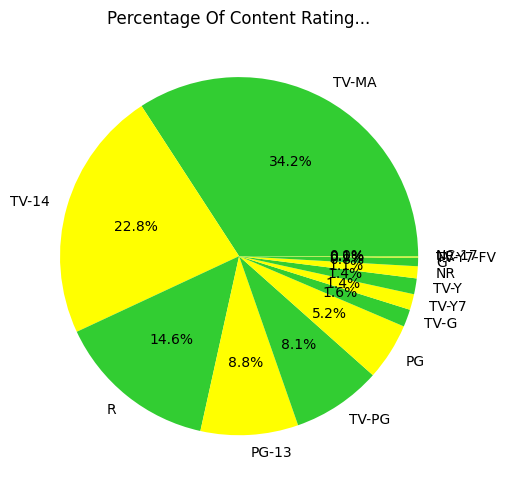

In [37]:
rating_counts = df["rating"].value_counts()
plt.figure(figsize = (10, 5))
plt.pie(rating_counts , labels=rating_counts.index ,autopct='%1.1f%%' , colors=['limegreen' , 'yellow'])
plt.title("Percentage Of Content Rating...")
plt.tight_layout()
plt.savefig("Content_Rating_Pie.png")
plt.show

Q-3.. How Has The Number Of Release Changed Over The Years... Chart Type - Line_plot...

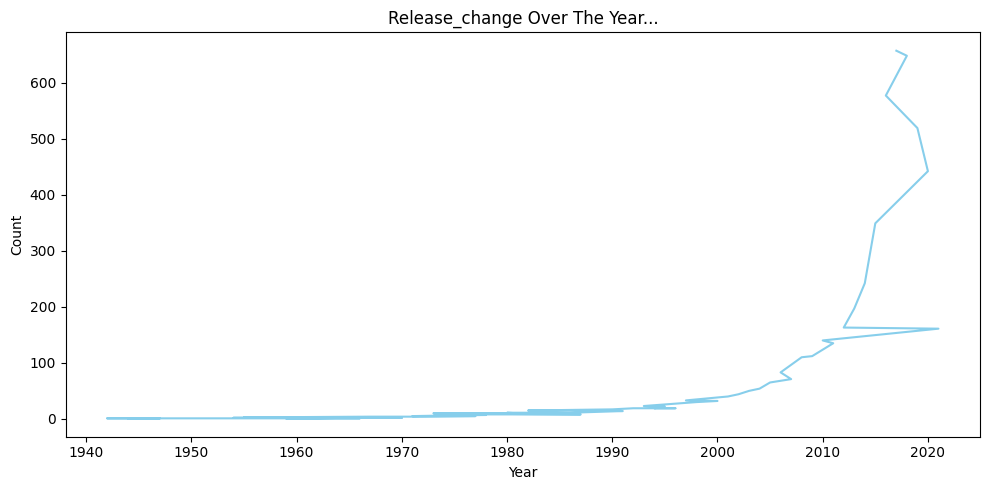

In [49]:
release_change = df['release_year'].value_counts()
plt.figure(figsize=(10,5))
plt.plot(release_change.index , release_change.values , color = 'skyblue')
plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Release_change Over The Year...")
plt.tight_layout()
plt.savefig("Number Of Release Change.png")
plt.show()

Q-4 .. What Is the Distribution Of Movie Duration... Chart Type - Histogram...

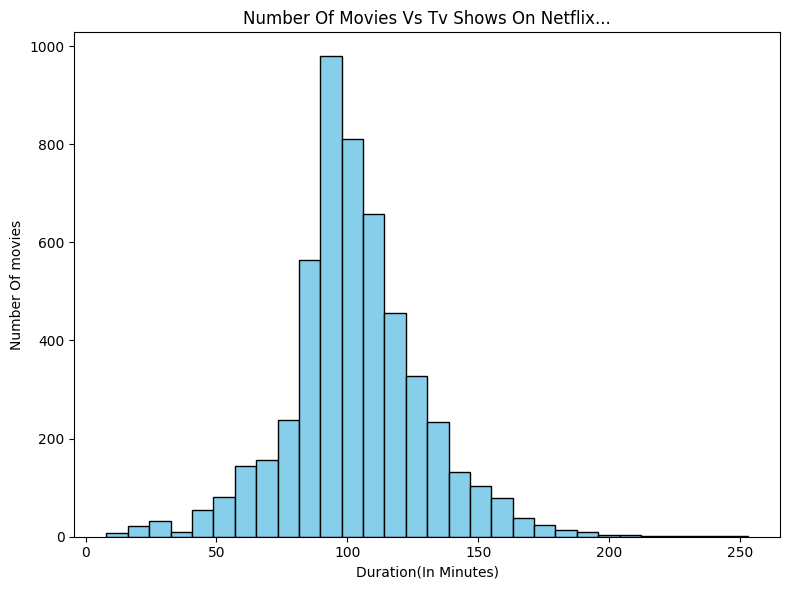

In [75]:
movie_df = df[df['type'] == 'Movie'].copy()
movie_df['duration_int'] = (movie_df['duration'].str.replace('min', '').astype(int))

plt.figure(figsize=(8,6))
plt.hist(movie_df['duration_int'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel("Duration(In Minutes)")
plt.ylabel("Number Of movies")
plt.title("Number Of Movies Vs Tv Shows On Netflix...")
plt.tight_layout()
plt.savefig("Movies_Duration_Histogram.png")
plt.show()

Q-5 ... Relatinship Between release Year And Number Of Shows... plot - Scatter....

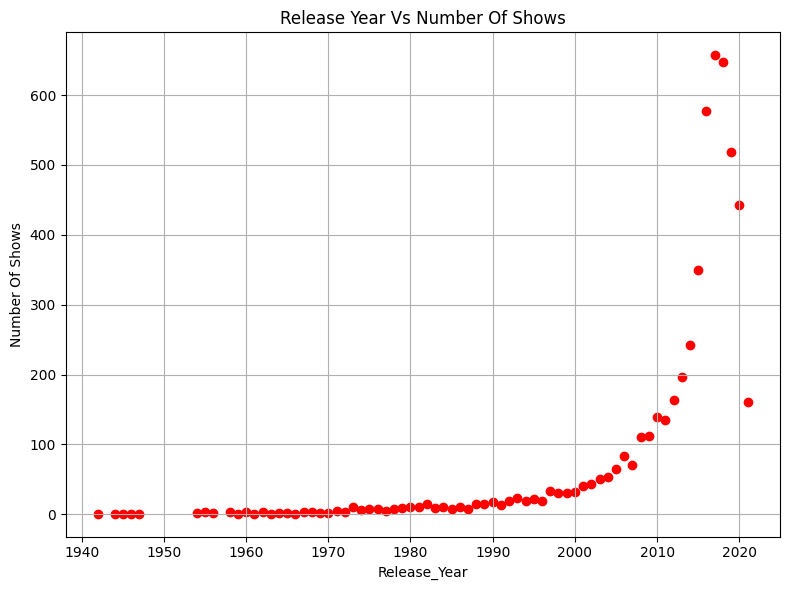

In [87]:
release_counts = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(8,6))

plt.scatter(release_counts.index , release_counts.values , color = 'red', marker='o')
plt.xlabel("Release_Year")
plt.ylabel("Number Of Shows")
plt.title("Release Year Vs Number Of Shows")
plt.grid()
plt.tight_layout()
plt.savefig("Release_Year_Scatter.png")
plt.show()

Q-6 .. Top 10 Countries With The Highest Number Of Shows...
Bar Chart Horizontal..

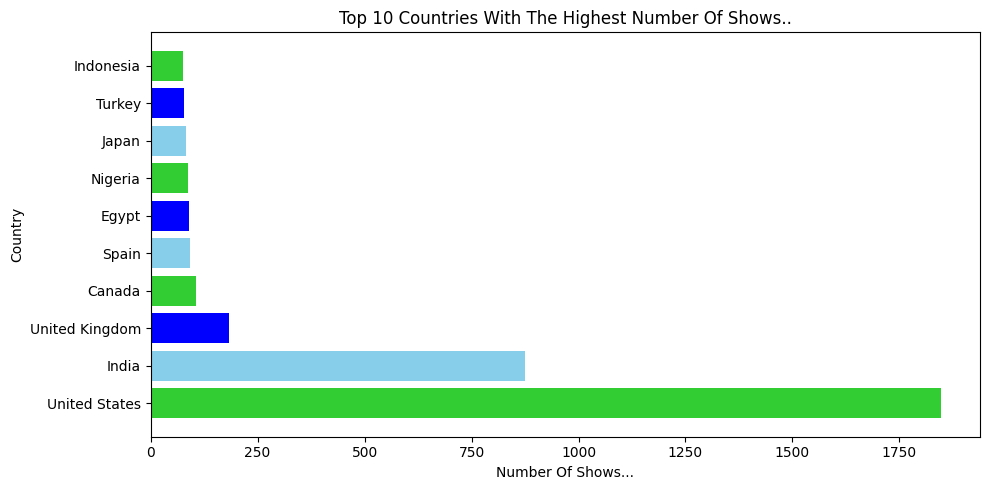

In [96]:
highest_counts = df['country'].value_counts().head(10)
plt.figure(figsize=(10,5))

plt.barh(highest_counts.index , highest_counts.values , color = ['limegreen' , 'skyblue' , 'blue'])
plt.xlabel("Number Of Shows...")
plt.ylabel("Country")
plt.title("Top 10 Countries With The Highest Number Of Shows..")
plt.tight_layout()
plt.savefig("Top_10_Countries.png")

plt.show()

Q-7.. Compare Multiple Plots Together (e.g. Movies Vs Tv shows By Year...)   Subplots...

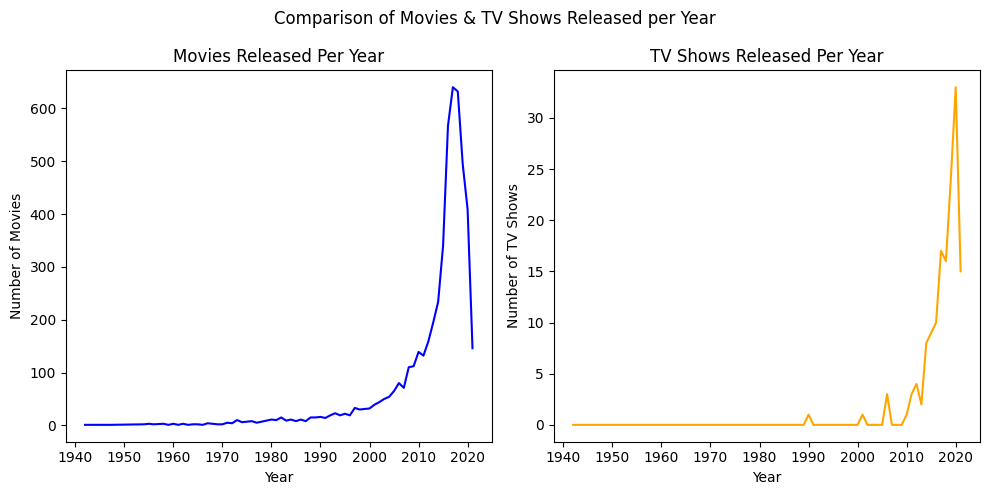

In [109]:
content_by_year = df.groupby(['release_year', 'type']).size().unstack().fillna(0)

fig, ax = plt.subplots(1, 2, figsize=(10,5))

# Movies

ax[0].plot(content_by_year.index, content_by_year['Movie'], color='blue')
ax[0].set_title("Movies Released Per Year")
ax[0].set_xlabel("Year")
ax[0].set_ylabel("Number of Movies")

# TV Shows

ax[1].plot(content_by_year.index, content_by_year['TV Show'], color='orange')
ax[1].set_title("TV Shows Released Per Year")
ax[1].set_xlabel("Year")
ax[1].set_ylabel("Number of TV Shows")

fig.suptitle("Comparison of Movies & TV Shows Released per Year")
plt.tight_layout()
plt.savefig("Comparison Of Movies & Tv Shows.png")
plt.show()